In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys, os
sys.path.append(os.path.abspath('../..'))
import torch
import torch.nn as nn

from mounirood.tester import PonderationTester
from mounirood.datasets import get_y
from mounirood.framework import FrameworkFactory
from mounirood.modality_fusion import calc_perturbations, CoefficientPonderator
from mounirood.datasets import get_dataloader, get_y
from mounirood.eval_functions import visualize, train, performance_report
#from mounirood.eval_functions import auc_and_fpr_recall, visualize, calc_outputs_test, calc_correlations, separabilite
from sklearn import metrics
from sklearn.model_selection import train_test_split
from mounirood.classifier import Classifier

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
torch.cuda.is_available()

Matplotlib created a temporary cache directory at /tmp/matplotlib-u7akc533 because the default path (/local/maouche/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/maouche/.conda/envs/multiood/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Near OOD

## Création des datasets

In [ ]:
framework = FrameworkFactory("near_ood")
layer_proc = "ash"

conf = framework.get_confs("id", layer_proc)
pred = framework.get_preds_near_vf("id", layer_proc)
labels = framework.get_saved_files_near_vf("label", "id", layer_proc)

failure_gt = {}
for dataset_name, values in list(pred.items()):
    failure_gt[dataset_name] = np.where(pred[dataset_name].transpose()[0] == labels[dataset_name].transpose()[0], 0, 1).reshape(-1,1) # 1 == Failure
    
X = conf
Y = failure_gt
datasets = ["HMDB", "UCF", "EPIC"]
data = {}
for dataset in datasets:    
    X_train, X_test, y_train, y_test = train_test_split(
                    X[dataset], Y[dataset], stratify=Y[dataset], test_size=0.2, random_state=42)

    data[dataset] = {"X_train":X_train, "y_train": y_train, "X_test": X_test, "y_test": y_test}

In [ ]:
with open("data_near.pkl", 'wb') as f:
    pickle.dump(data, f)

## HMDB

In [ ]:
# Ajouter une variable pour layer_proc
classifier = Classifier(FrameworkFactory(ood_mode="near_ood", dataset_used="HMDB")
                        , dims=[4,1])
classifier.calc_class_weight()

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


cuda
accuracy train:  0.8794341286023458


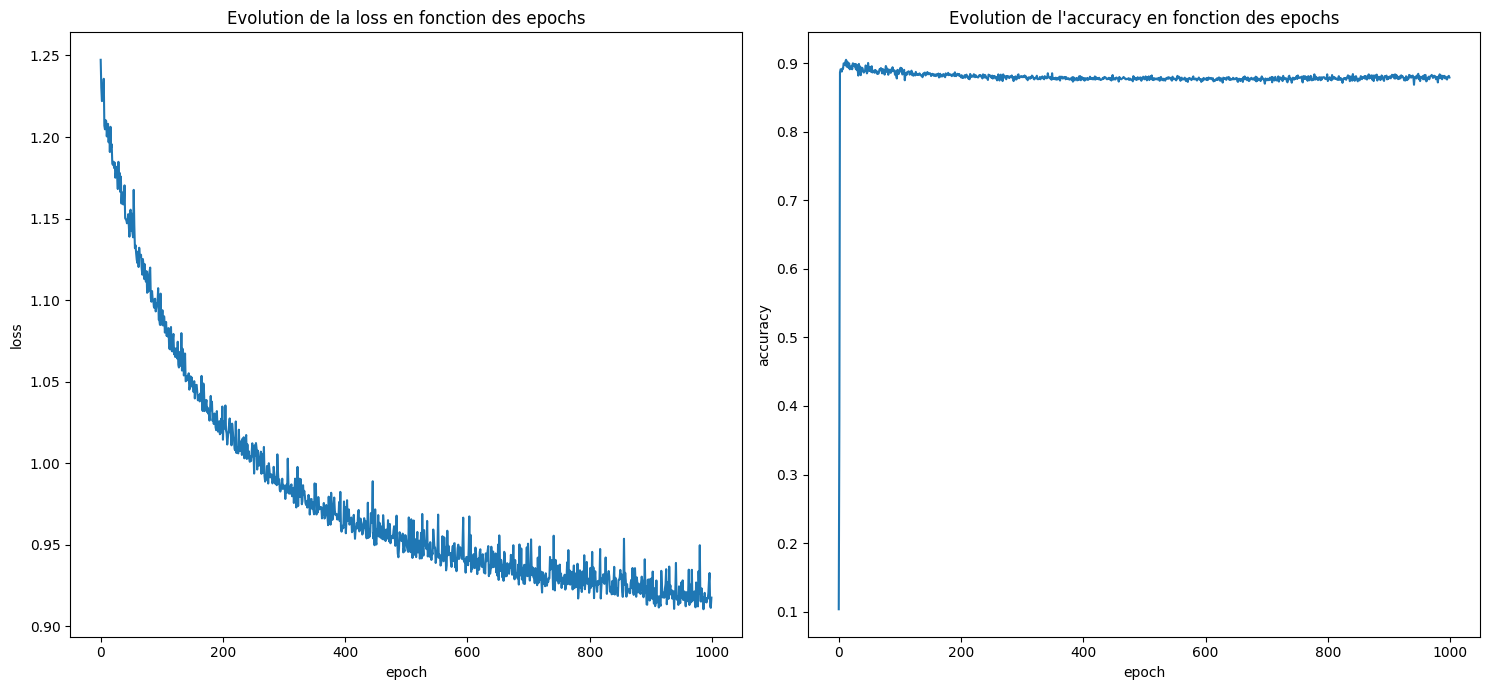

cuda
accuracy train:  0.8501783013343811


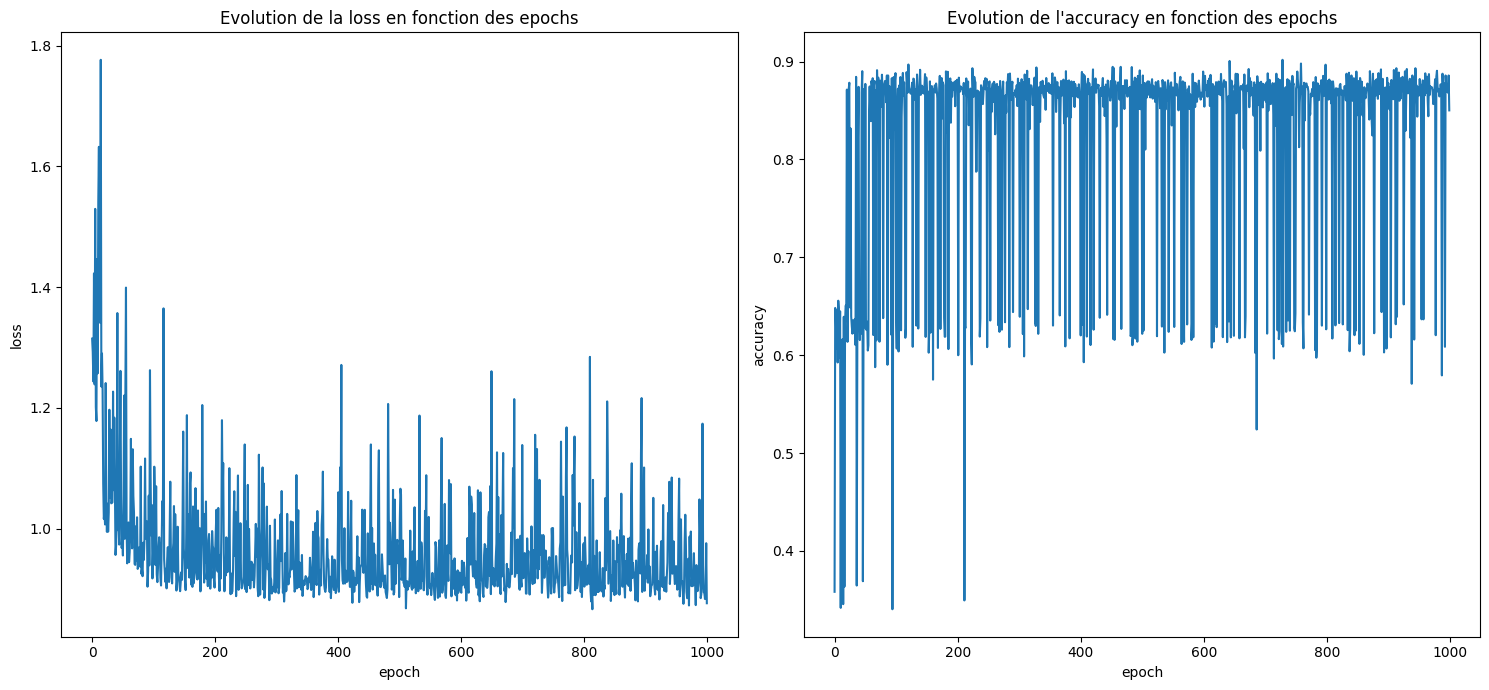

cuda
accuracy train:  0.8928537964820862


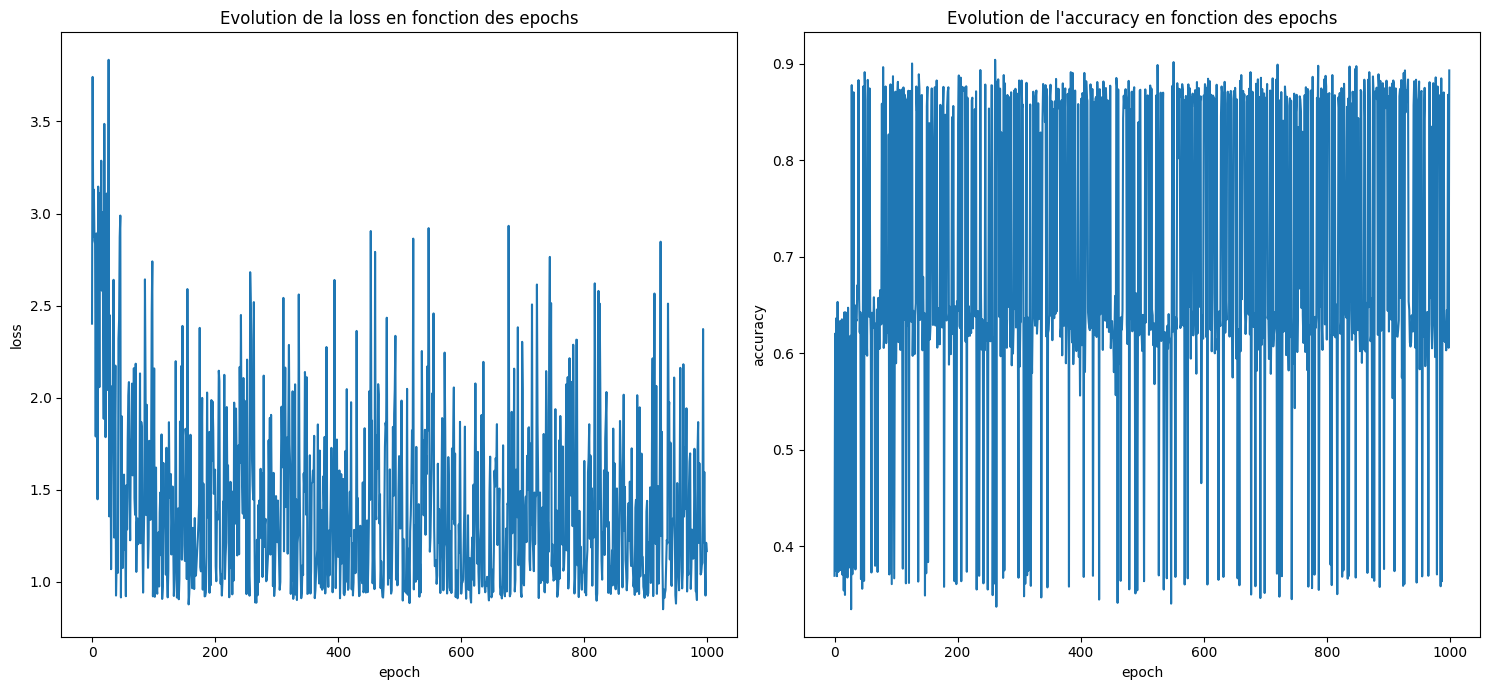

In [26]:
classifier.train_models()

In [27]:
classifier.save_best_model()

Accuracy test:  0.1087
Séparabilité:


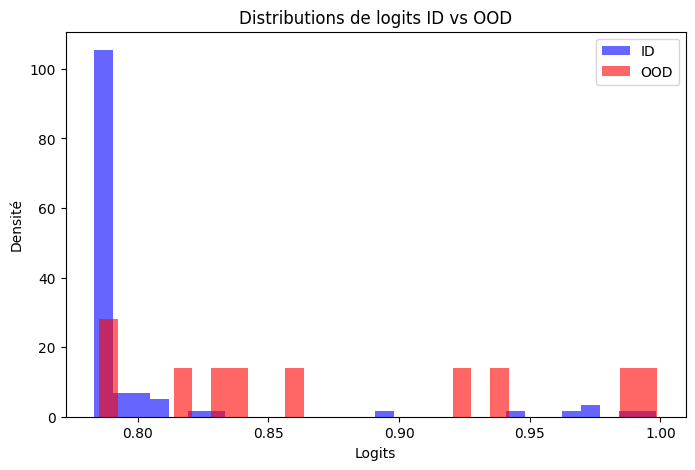

AUC ROC: 0.889
FPR@TPR95: 0.2927

Correlation ID :  0.96062444522029
Correlation OOD :  0.8398859836513848


,config,tout,video,flow
0,poids_near_ood,11.3157,-1.0176,-5.1180
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0203,0.0163,0.0036


In [29]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = classifier.performance_report()

## UCF

In [ ]:
# Ajouter une variable pour layer_proc
classifier = Classifier(FrameworkFactory(ood_mode="near_ood", dataset_used="UCF")
                        , dims=[4,1])
classifier.calc_class_weight()

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


cuda
accuracy train:  0.8794341286023458


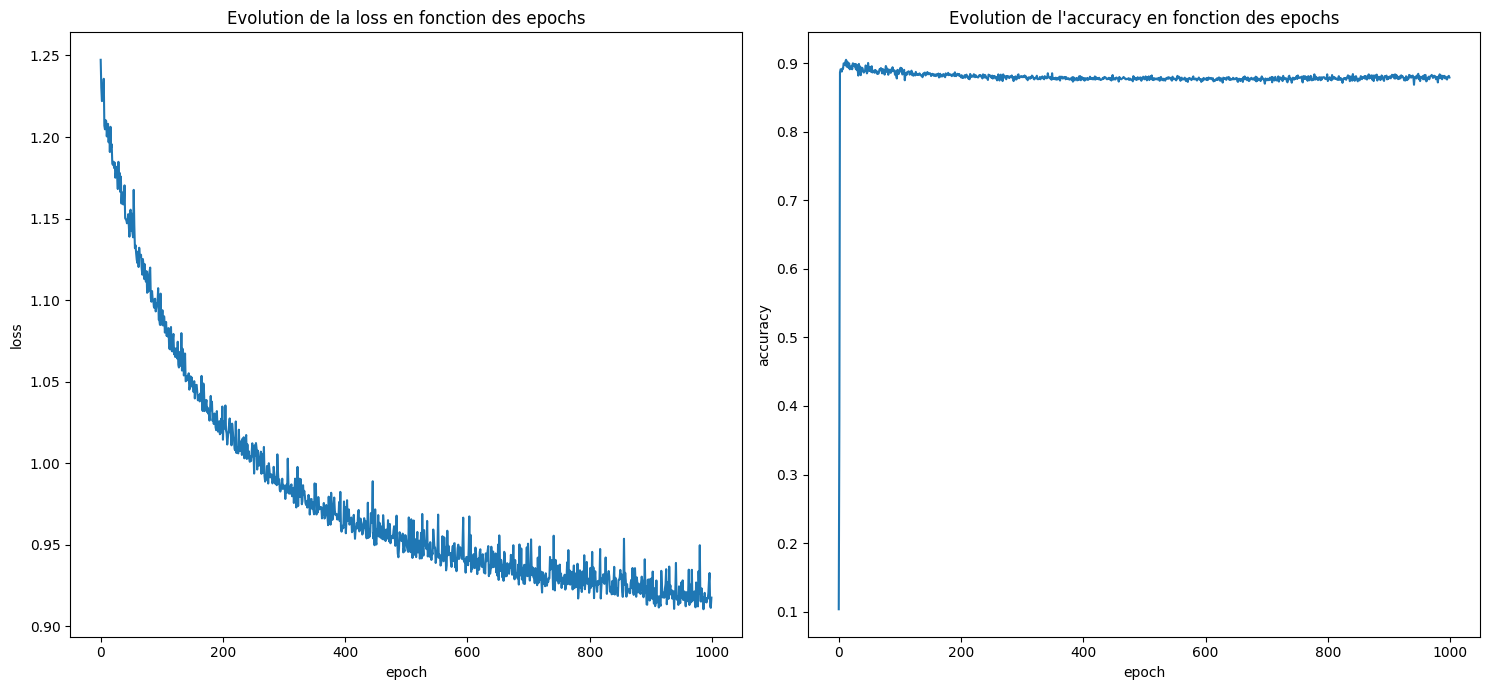

cuda
accuracy train:  0.8501783013343811


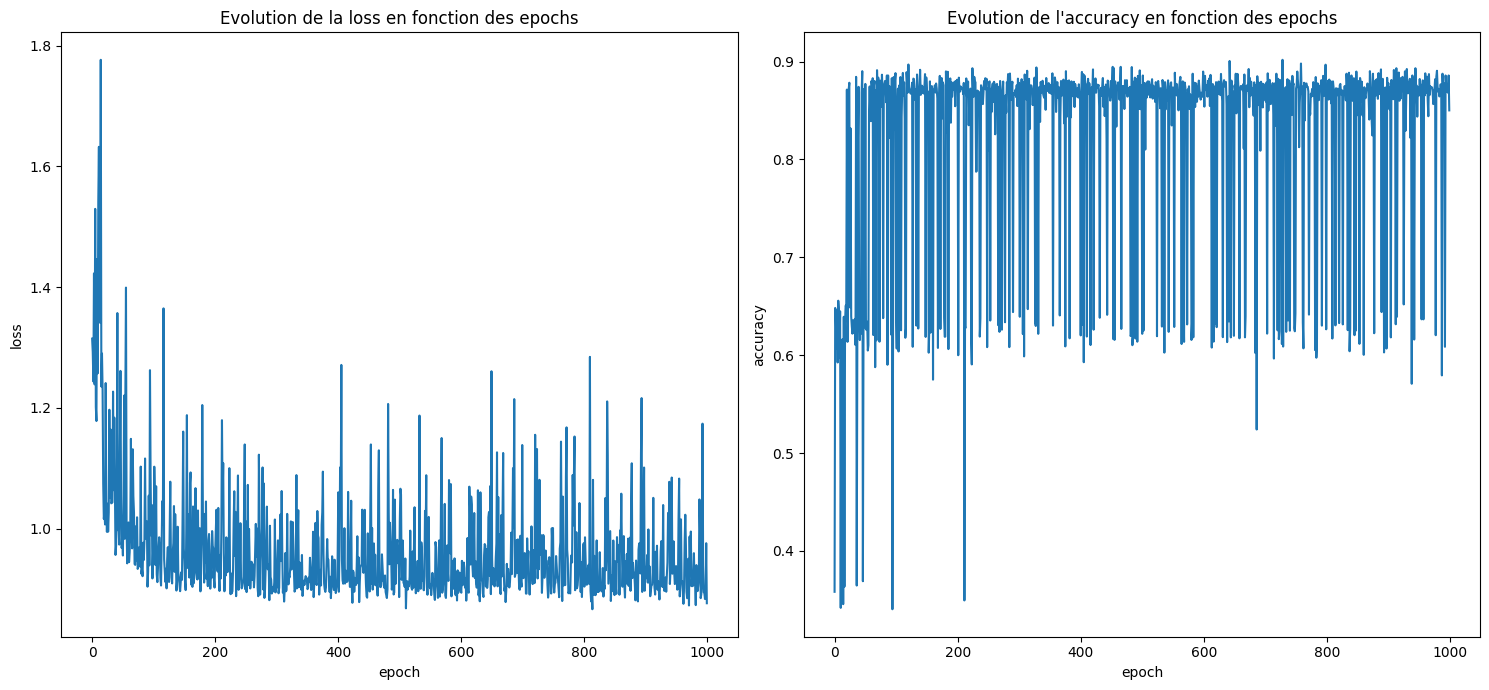

cuda
accuracy train:  0.8928537964820862


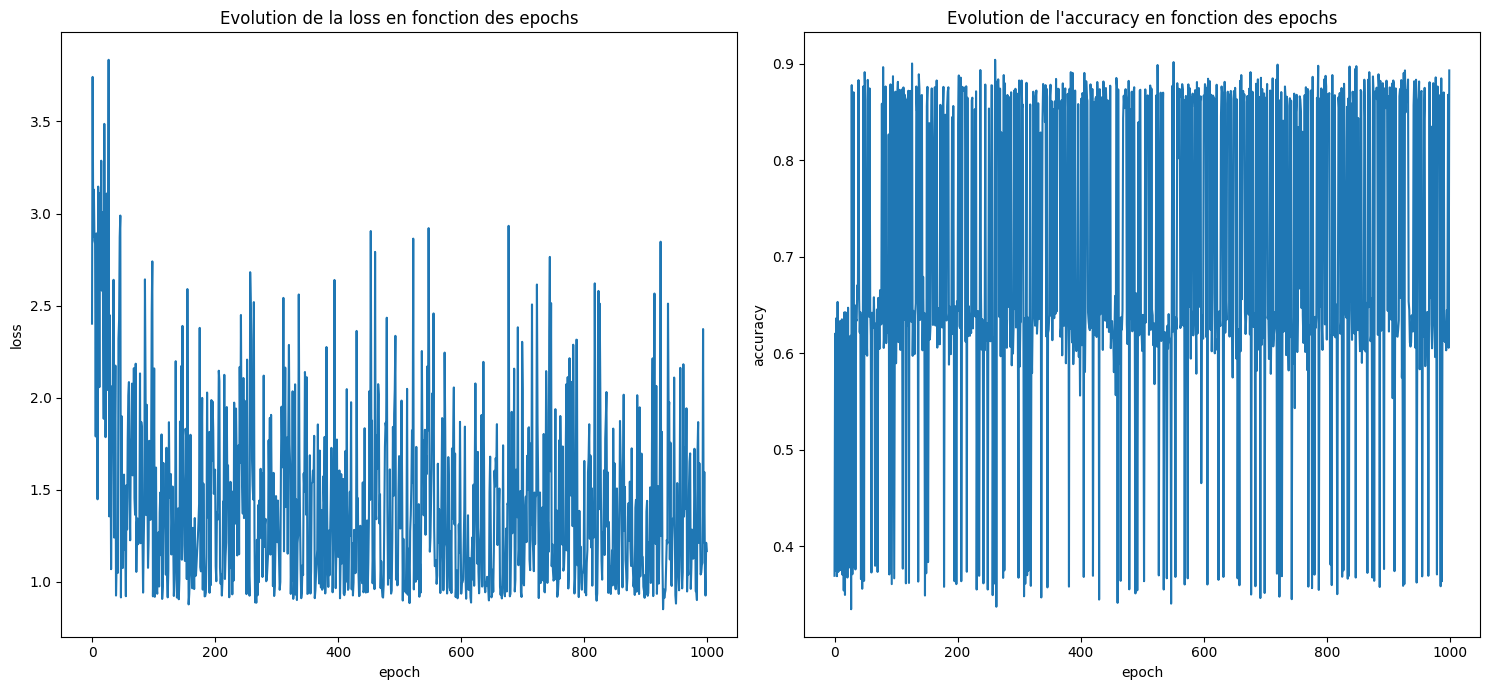

In [ ]:
classifier.train_models()

In [ ]:
classifier.save_best_model()

Accuracy test:  0.1087
Séparabilité:


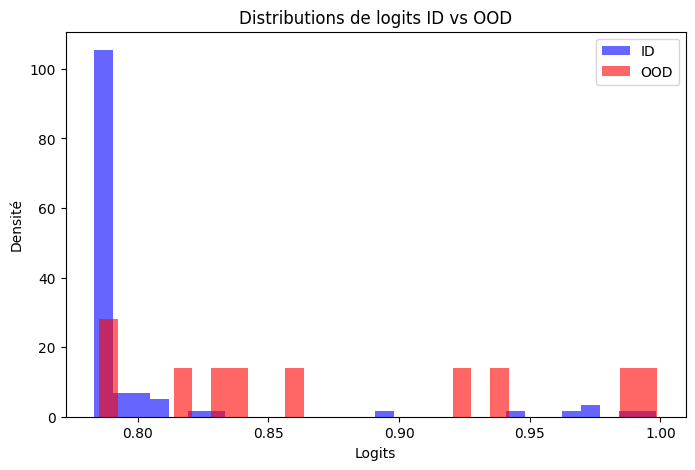

AUC ROC: 0.889
FPR@TPR95: 0.2927

Correlation ID :  0.96062444522029
Correlation OOD :  0.8398859836513848


,config,tout,video,flow
0,poids_near_ood,11.3157,-1.0176,-5.1180
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0203,0.0163,0.0036


In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = classifier.performance_report()

# EPIC

In [ ]:
# Ajouter une variable pour layer_proc
classifier = Classifier(FrameworkFactory(ood_mode="near_ood", dataset_used="EPIC")
                        , dims=[4,1])
classifier.calc_class_weight()

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


cuda
accuracy train:  0.8794341286023458


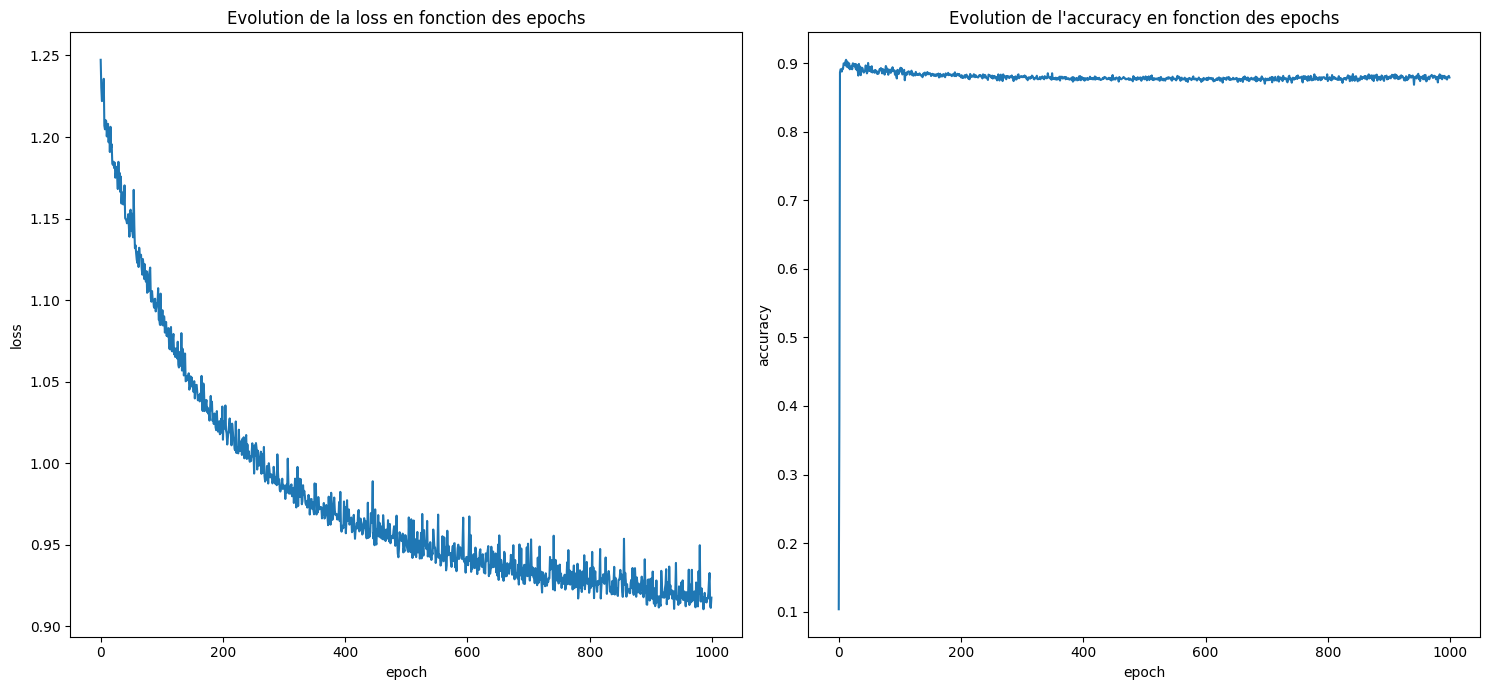

cuda
accuracy train:  0.8501783013343811


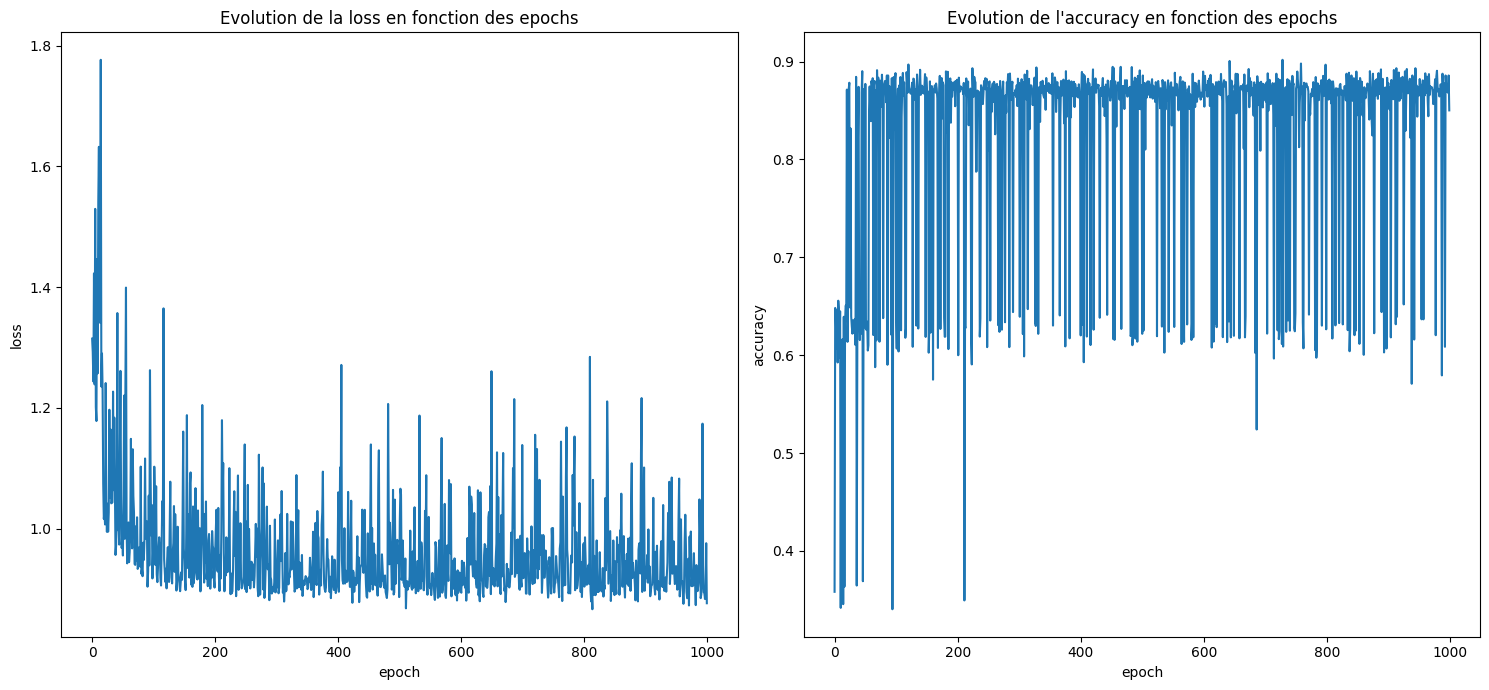

cuda
accuracy train:  0.8928537964820862


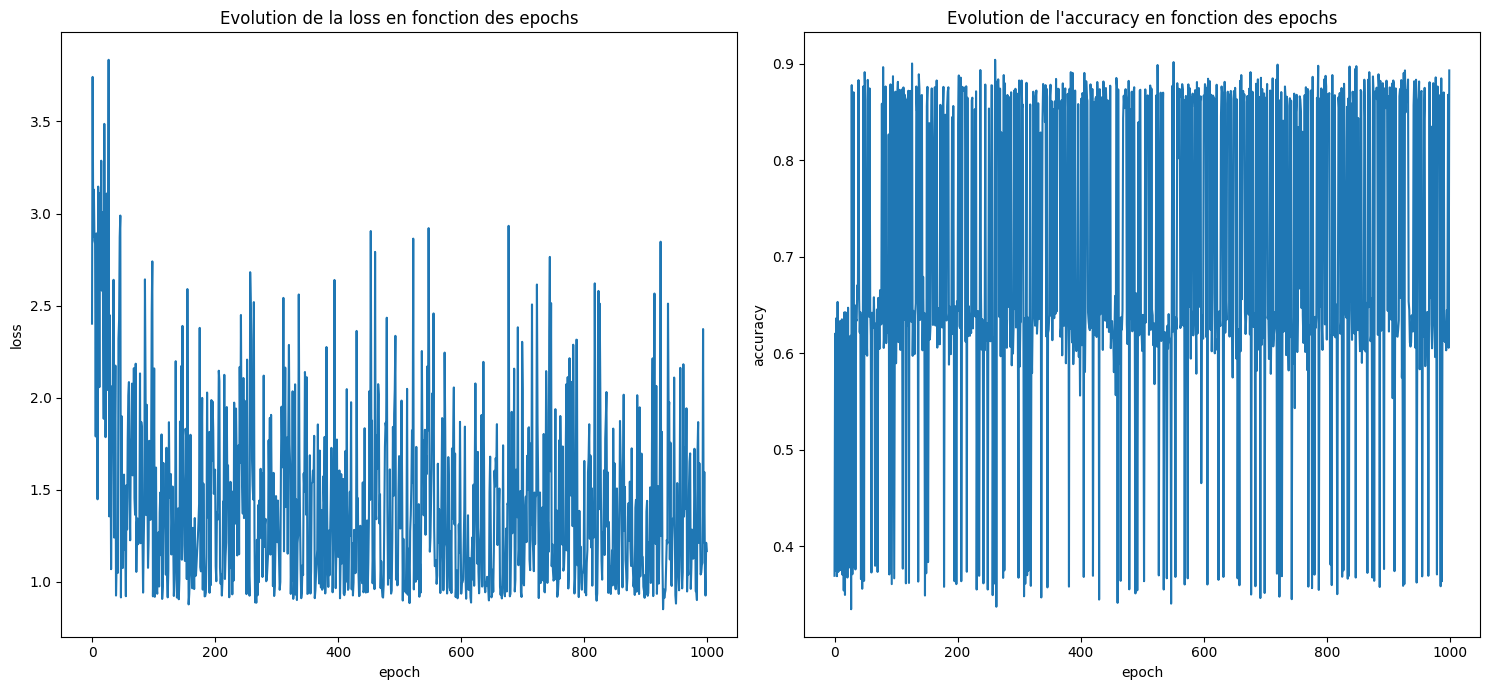

In [ ]:
classifier.train_models()

In [ ]:
classifier.save_best_model()

Accuracy test:  0.1087
Séparabilité:


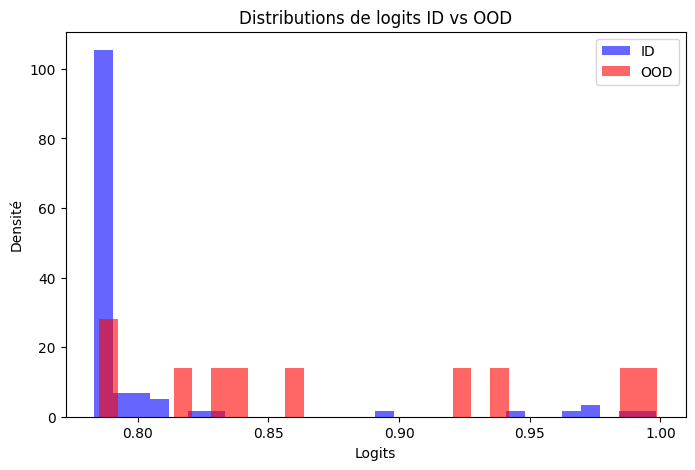

AUC ROC: 0.889
FPR@TPR95: 0.2927

Correlation ID :  0.96062444522029
Correlation OOD :  0.8398859836513848


,config,tout,video,flow
0,poids_near_ood,11.3157,-1.0176,-5.1180
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0203,0.0163,0.0036


In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = classifier.performance_report()

# VFA

In [ ]:
# Ajouter une variable pour layer_proc
classifier = Classifier(FrameworkFactory(ood_mode="vfa")
                        , dims=[4,1])
classifier.calc_class_weight()

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


cuda
accuracy train:  0.8794341286023458


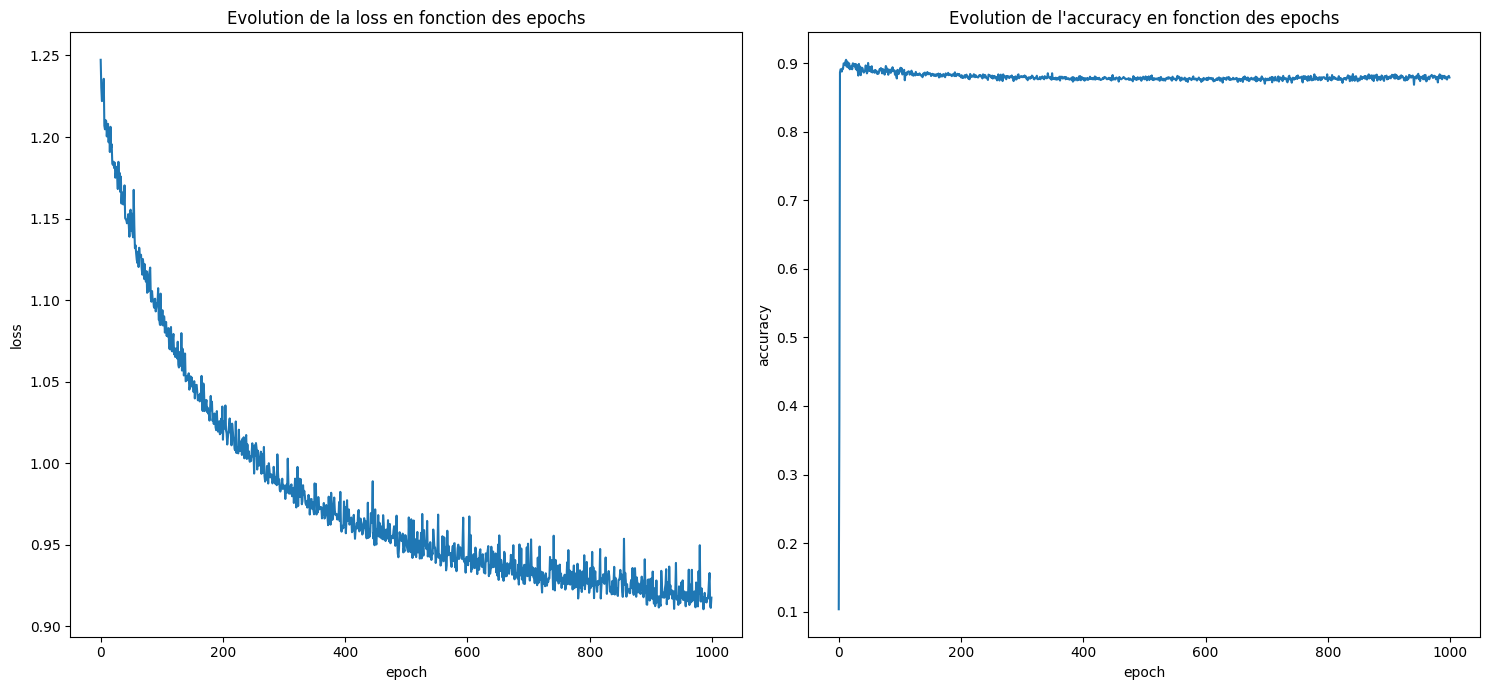

cuda
accuracy train:  0.8501783013343811


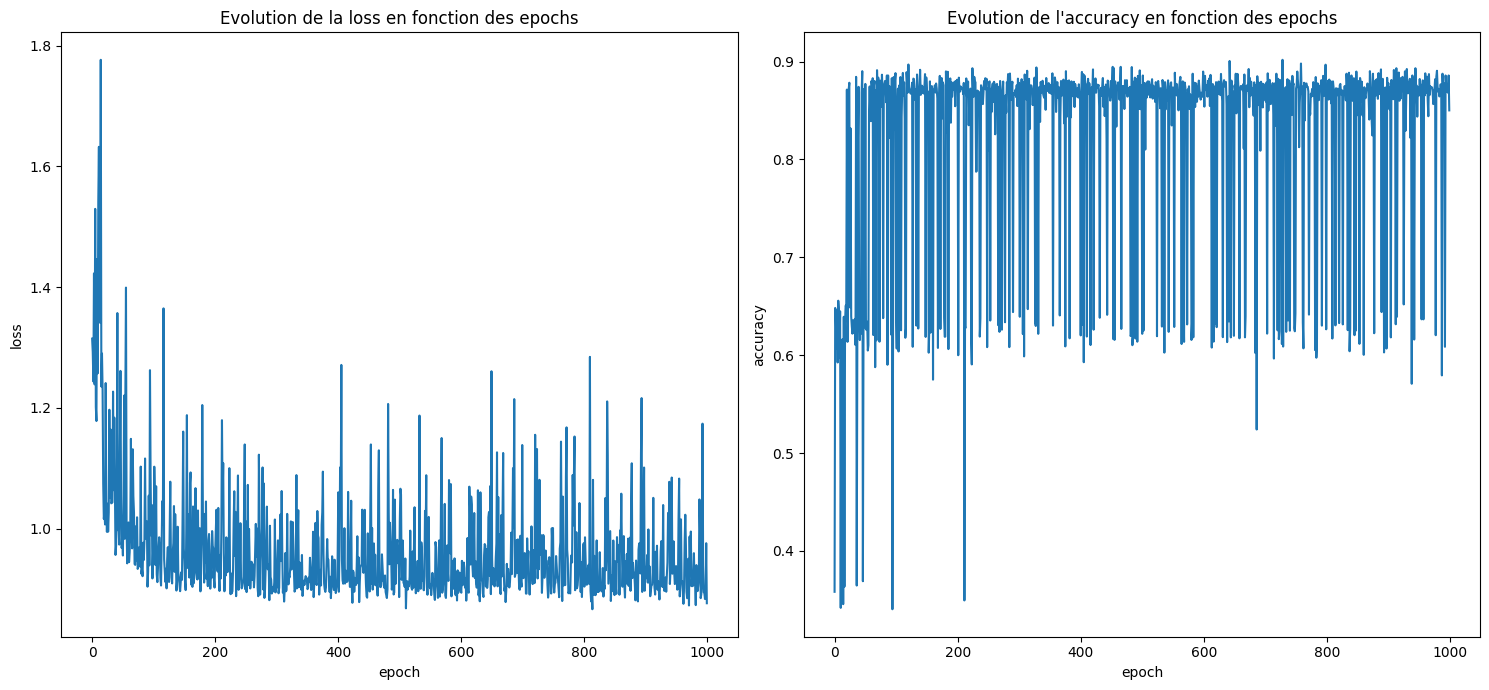

cuda
accuracy train:  0.8928537964820862


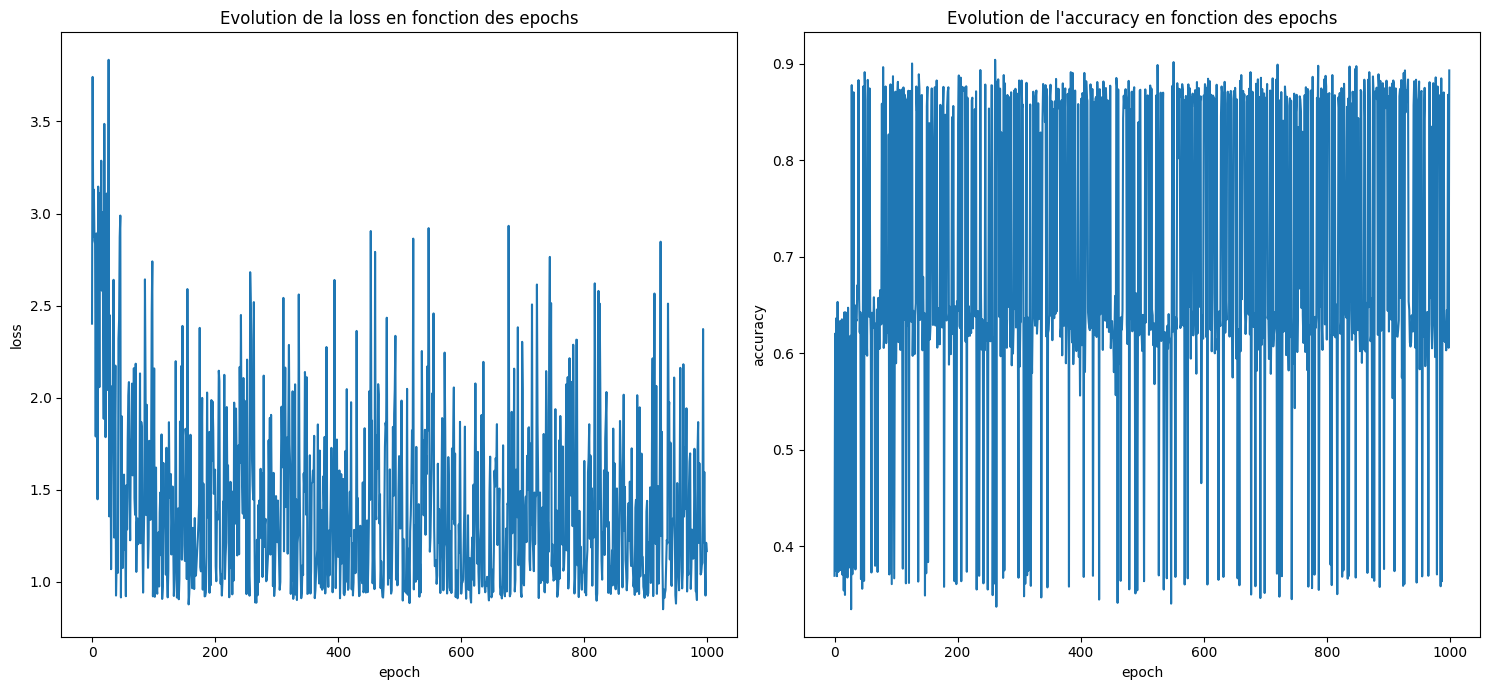

In [ ]:
classifier.train_models()

In [ ]:
classifier.save_best_model()

Accuracy test:  0.1087
Séparabilité:


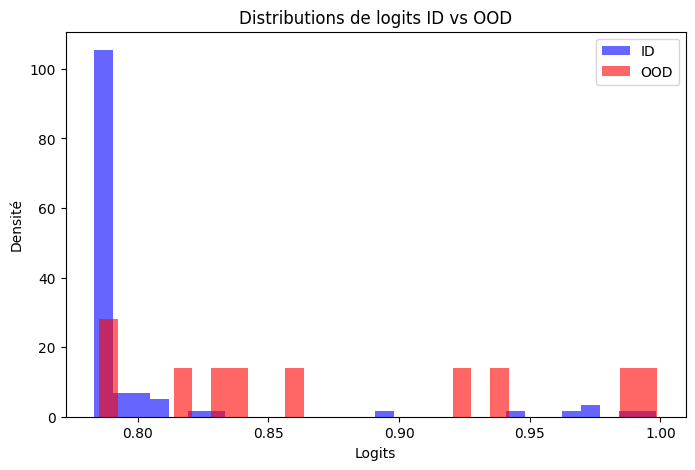

AUC ROC: 0.889
FPR@TPR95: 0.2927

Correlation ID :  0.96062444522029
Correlation OOD :  0.8398859836513848


,config,tout,video,flow
0,poids_near_ood,11.3157,-1.0176,-5.1180
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0203,0.0163,0.0036


In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = classifier.performance_report()

# Far OOD

In [ ]:
# Ajouter une variable pour layer_proc
classifier = Classifier(FrameworkFactory(ood_mode="far_ood")
                        , dims=[4,1])
classifier.calc_class_weight()

367 elements (array([0., 1.], dtype=float32), array([329,  38]))
92 elements (array([0., 1.], dtype=float32), array([82, 10]))


cuda
accuracy train:  0.8794341286023458


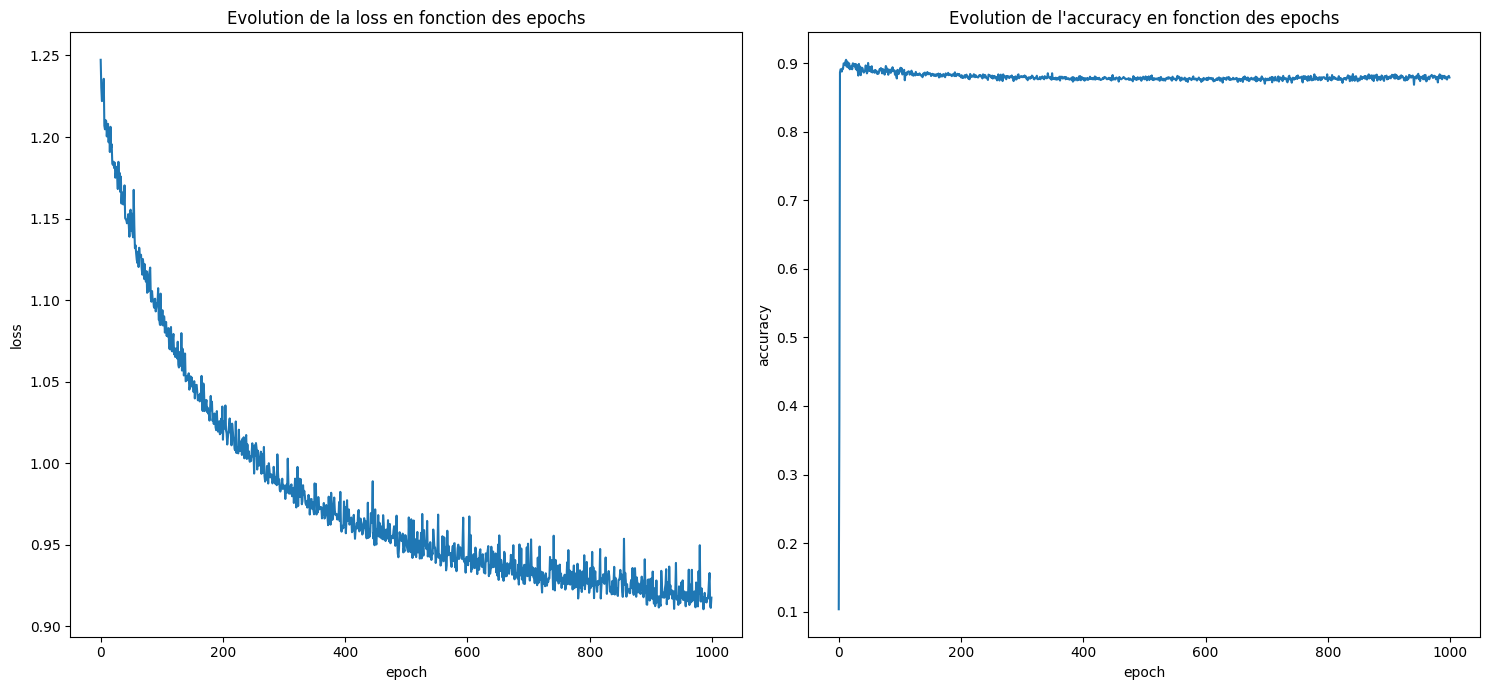

cuda
accuracy train:  0.8501783013343811


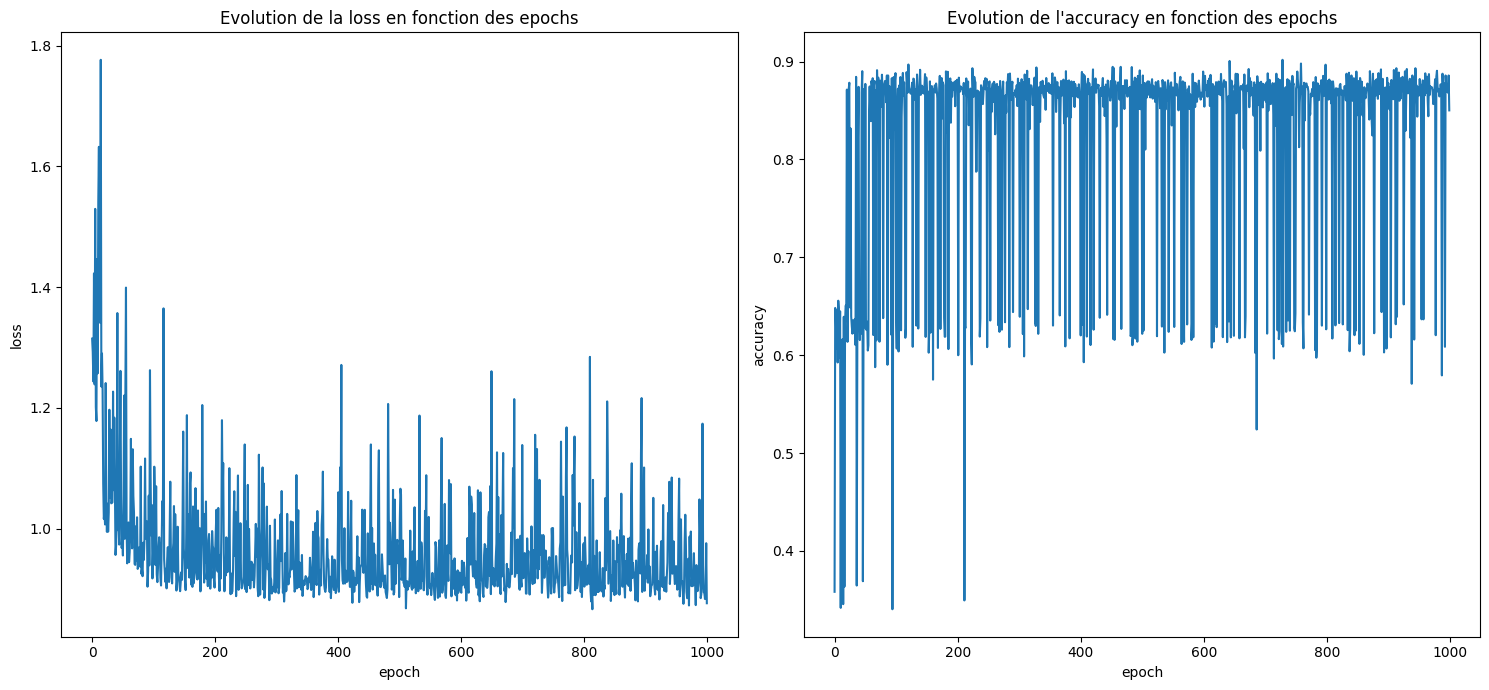

cuda
accuracy train:  0.8928537964820862


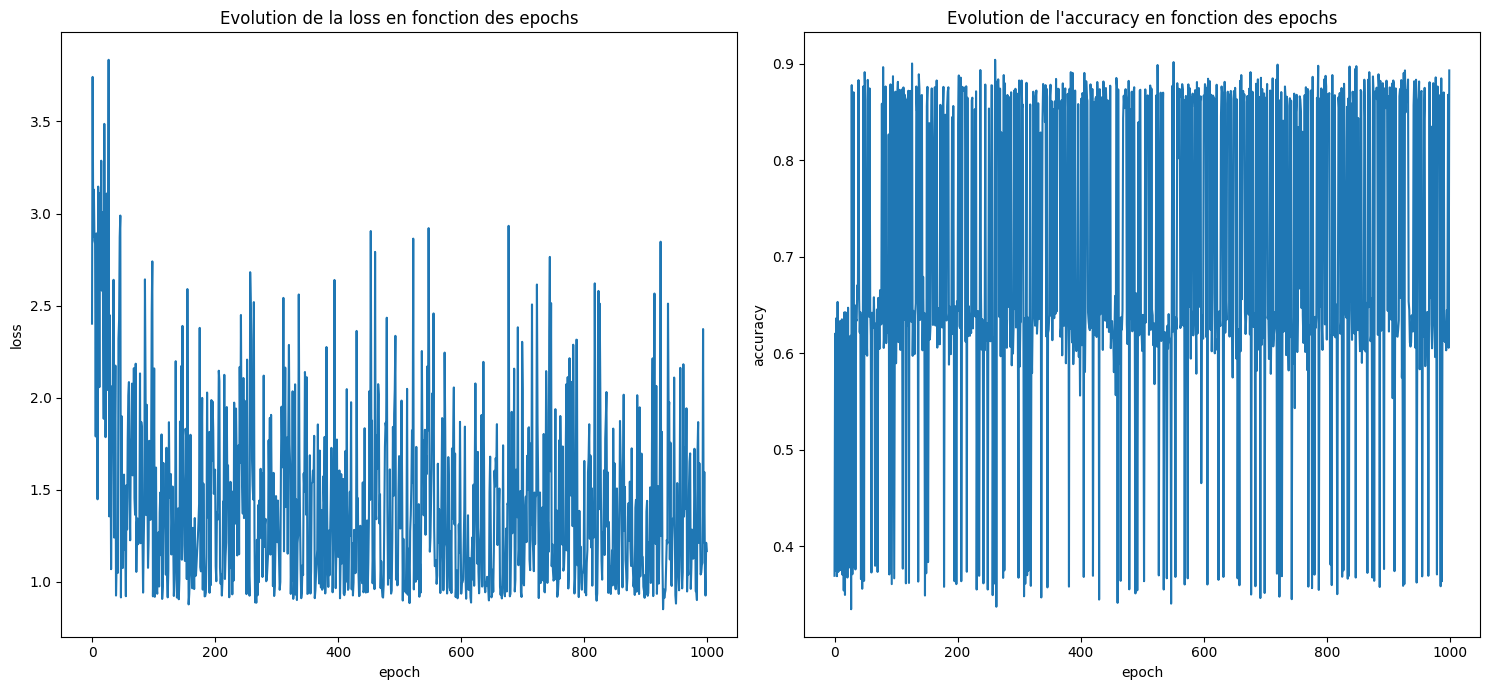

In [ ]:
classifier.train_models()

In [ ]:
classifier.save_best_model()

Accuracy test:  0.1087
Séparabilité:


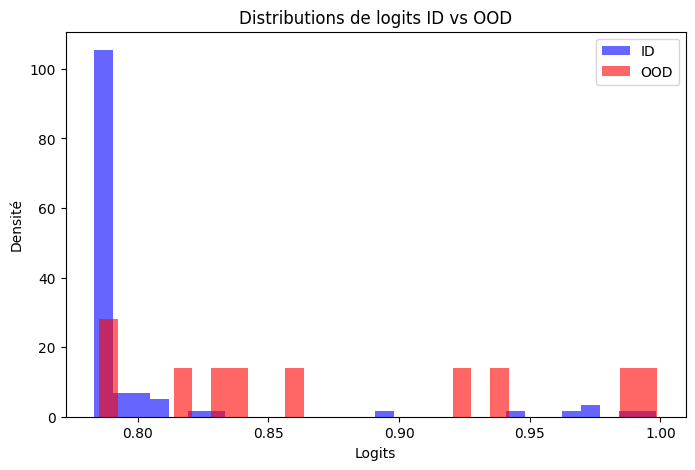

AUC ROC: 0.889
FPR@TPR95: 0.2927

Correlation ID :  0.96062444522029
Correlation OOD :  0.8398859836513848


,config,tout,video,flow
0,poids_near_ood,11.3157,-1.0176,-5.1180
1,perturbation_near_ood_id,0.0052,0.0035,0.0018
2,perturbation_near_ood_ood,0.0203,0.0163,0.0036


In [ ]:
outputs_test, auroc, fpr, df, correlation_id, correlation_ood = classifier.performance_report()